In [23]:
import MDAnalysis as mda
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from pathlib import Path

from statsmodels.stats.diagnostic import lilliefors

In [24]:
%load_ext autoreload
%autoreload 1

%aimport sb_bond_functions
%aimport shap_functions

import sb_bond_functions as ba
import shap_functions

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
DATA = Path("/home/romiromi/work/bond_analysis/bondflow_data")

reference_struc = DATA /'active_mini_proteinonly.gro'#'centered_active.gro' 
trajectory = [DATA / 'aligned_trajectory.xtc'] #['test.xtc'] 
inactive = DATA / 'aligned_inactive.gro'

In [26]:
all_pairs, current_pairs, categorized_contacts, combined_coords, n_mainchain_residues, pvalue_df = ba.compute_com_contacts(trajectory, reference_struc, 
                        batch_size=100, stride=1, 
                        mc_contact_threshold=8.0, sc_contact_threshold=8.0, 
                        mc_sc_contact_threshold=8.0, variance_percentile=75, pvalue_threshold=0.05,
                        n_jobs=1)

aligned_trajectory.xtc: 100%|██████████| 11/11 [00:00<00:00, 175.52it/s]


Mainchain-Mainchain pairs: 544446
Sidechain-Sidechain pairs: 544446
Mainchain-Sidechain pairs: 1089936


Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:00<00:00, 5582.46it/s]


MC-MC pairs after contact filter: 6,553


Stage 1: Contact Filter:   0%|          | 0/5445 [00:00<?, ?it/s]/home/romiromi/work/bond_analysis/bondflow/salt_bridge_analysis/sb_bond_functions.py:173: RuntimeWarning: All-NaN slice encountered
  min_distances = np.nanmin(batch_distances, axis=0)
Stage 1: Contact Filter: 100%|██████████| 5445/5445 [00:01<00:00, 5294.88it/s]


...

MC-SC pairs after contact filter: 8,069
Total pairs after Stage 1 (all classes): 17,672


Stage 2: Calculating Variances: 100%|██████████| 177/177 [00:00<00:00, 2656.16it/s]


Pairs after variance filter: 4,418


Stage 3: Calculating Distributions: 100%|██████████| 45/45 [00:02<00:00, 16.58it/s]


Pairs after distribution filter: 948


In [27]:
# Create a distance dataframe to look at salt bridge distances 
# and their variance across the trajectory
model = mda.Universe(reference_struc, trajectory)
protein_residues = model.select_atoms("protein").residues
df = ba.compute_residue_pair_distances(combined_coords, current_pairs, n_mainchain_residues, protein_residues)
print(df.head())

                       pair_name bond_type  idx_i  idx_j    frame_0  \
0    ALA10_608(MC)_ASN11_609(SC)     MC-SC    608   1653   4.107812   
1    ALA10_608(MC)_SER41_639(SC)     MC-SC    608   1683   6.961919   
2    PRO39_637(MC)_LYS53_651(SC)     MC-SC    637   1695  10.228626   
3     THR40_638(MC)_LEU8_606(SC)     MC-SC    638   1650  10.895951   
4  SER257_855(MC)_VAL255_853(SC)     MC-SC    855   1897   7.705038   

     frame_1    frame_2    frame_3    frame_4    frame_5     frame_6  \
0   4.257218   5.231945   5.071724   5.099611   5.071301    5.119314   
1   7.651357   9.621007  10.477636   9.278526  13.629918  144.934820   
2  11.761234  12.242138  11.031232  10.969998  11.482594  146.055273   
3  13.312777  11.308836   9.859970  13.168509   5.926959  145.214084   
4   7.223622   7.654177   7.266521   7.727205   7.717253    7.664237   

      frame_7     frame_8    frame_9   frame_10  mean_distance  std_distance  
0    5.127495    3.926747   5.154198   3.910832       4.73438

In [28]:
# Removes duplicates based on resname and resnum!!!
unique_pairs = ba.remove_duplicate_pairs(current_pairs, protein_residues, n_mainchain_residues) 
print(f"Original pairs: {len(current_pairs)}")
print(f"Unique pairs:   {len(unique_pairs)}")

Original pairs: 948
Unique pairs:   679


In [29]:
# Search for salt bridges in the current pairs
binary_contact_map, distance_map, contact_map_names = ba.salt_bridge_contact_map_filtered(reference_struc, trajectory, current_pairs, distance_threshold=5.0)
print(binary_contact_map.shape)

print(distance_map.shape)

(10, 11)
(10, 11)


In [30]:
# Create sorted distance dataframe to look at salt bridge distances 
# and their variance across the trajectory/trajectories
dist_df, sb_names, std_df = ba.create_sorted_distance_dataframe(contact_map_names, binary_contact_map, distance_map)

In [31]:
print(dist_df.head())

Salt bridge  ARG540_GLU541  LYS13_GLU17  ASP558_ARG518  GLU48_LYS51  \
0                 4.076878     4.351715       8.979161     3.975764   
1                 7.592169     4.243422       7.553186     3.814370   
2                 4.203002     4.045853       5.154289     4.387139   
3                 9.326721     4.150686       4.716633     3.574016   
4                 8.180444     4.550076       4.652874     4.257947   

Salt bridge  LYS424_GLU433  GLU365_ARG426  LYS511_ASP558  GLU468_ARG470  \
0                 3.724112       9.333238       8.451097       5.748472   
1                 3.807016       9.535626       8.204719       7.252714   
2                 3.949562      10.406557       3.927274       6.328376   
3                 5.115561       9.381118       4.299141       5.302252   
4                 4.416988       9.238886       4.526922       6.727298   

Salt bridge  GLU433_ARG426  
0                 5.457352  
1                 5.311246  
2                 6.461169  
3     

IndexError: list index out of range

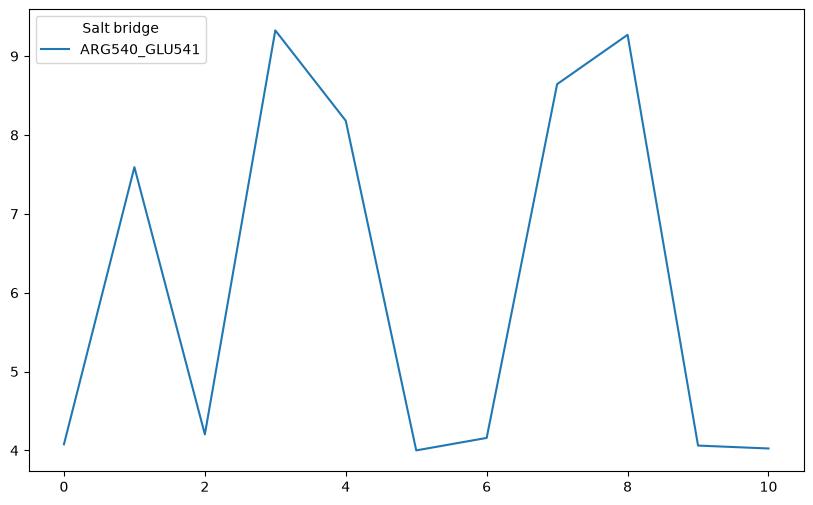

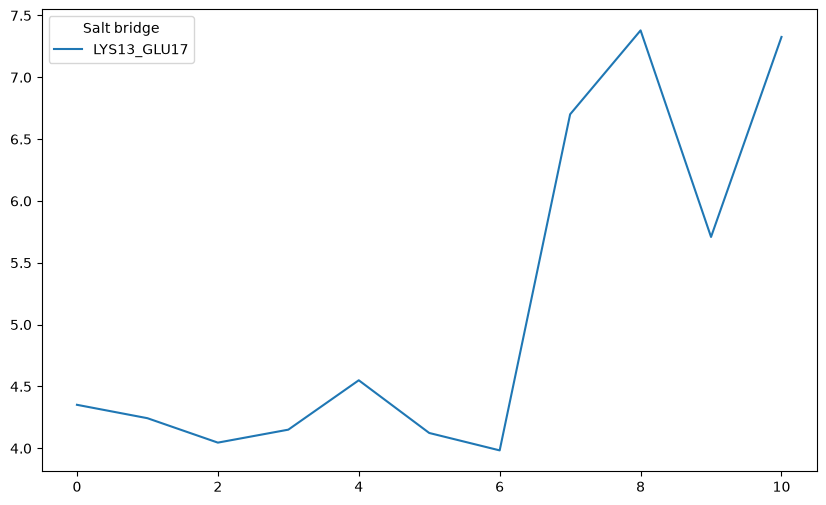

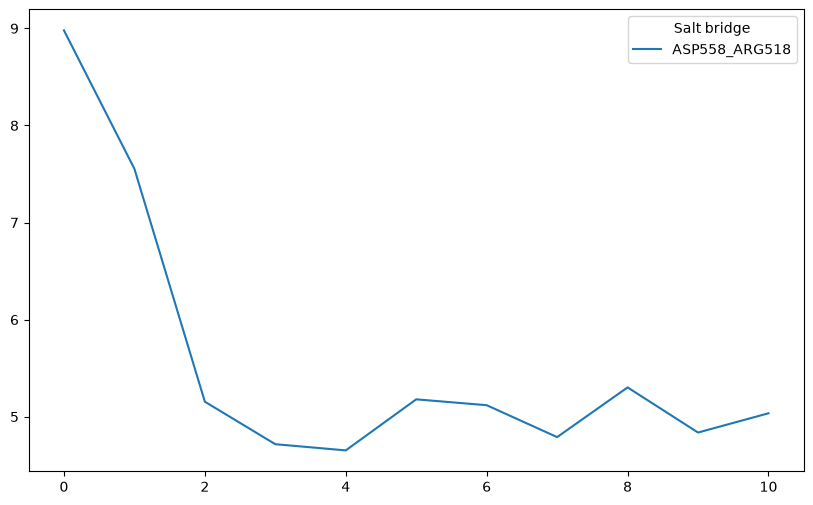

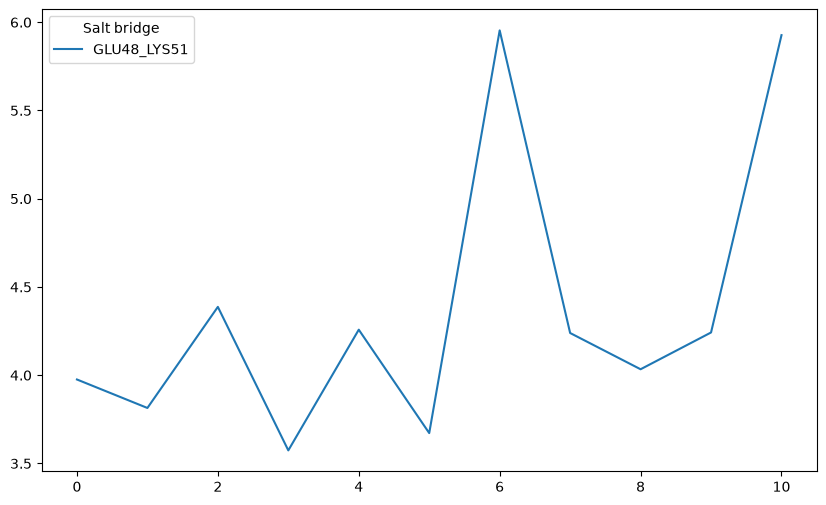

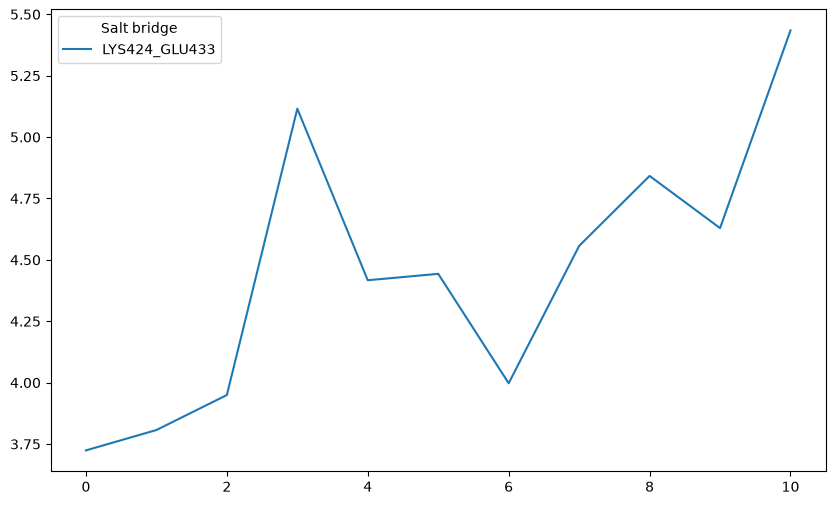

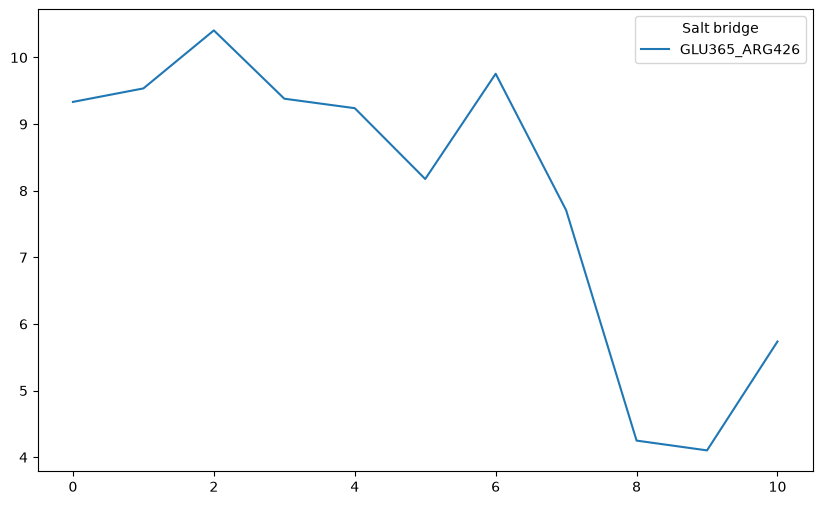

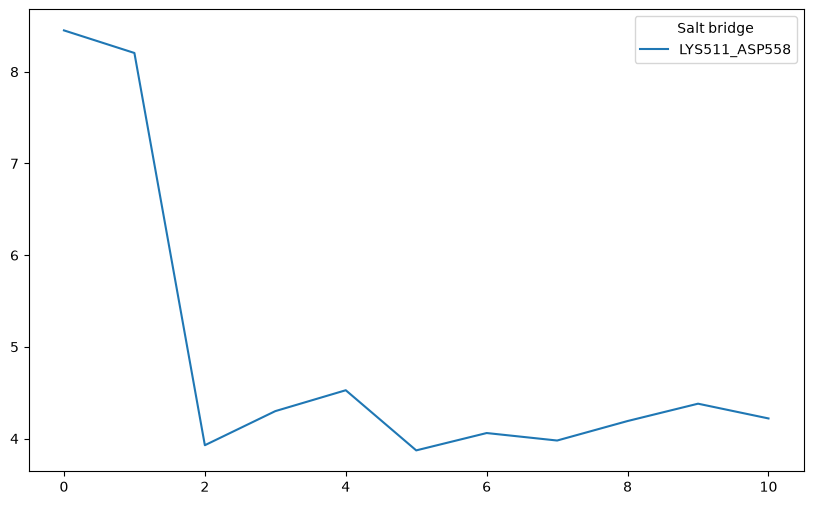

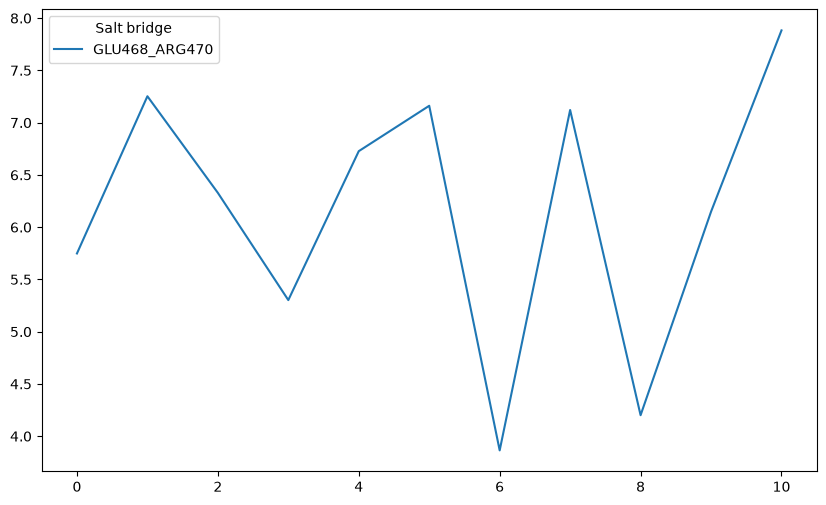

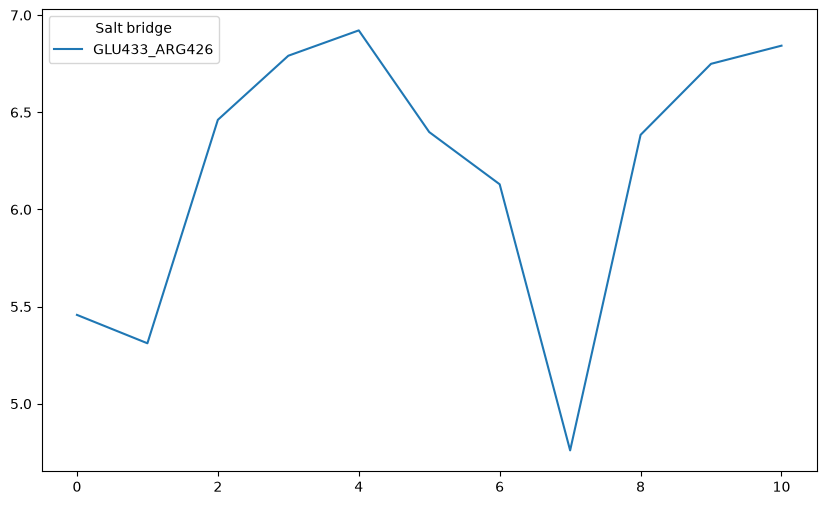

In [32]:
df2 = dist_df
sb_names = sb_names

df2.plot.line(y=[f'{sb_names[0]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[1]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[2]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[3]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[4]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[5]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[6]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[7]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[8]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[9]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[10]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[11]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[12]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[13]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[14]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[15]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[16]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[17]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[18]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[19]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[20]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[21]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[22]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[23]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[24]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[25]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[26]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[27]}'],  figsize=(10,6))
df2.plot.line(y=[f'{sb_names[28]}'],  figsize=(10,6))

## PLS ##

In [ ]:
# Here add the function data to be used in PLS

Y = np.load(DATA / "dot_products.npy")
print(Y.shape)

(11,)


In [36]:
X_scaled = shap_functions.scale_features(distance_map)
print(X_scaled.shape)
X_scaled = X_scaled.T
print(X_scaled.shape)

(10, 11)
(11, 10)


Done! Built models up to 4 components.


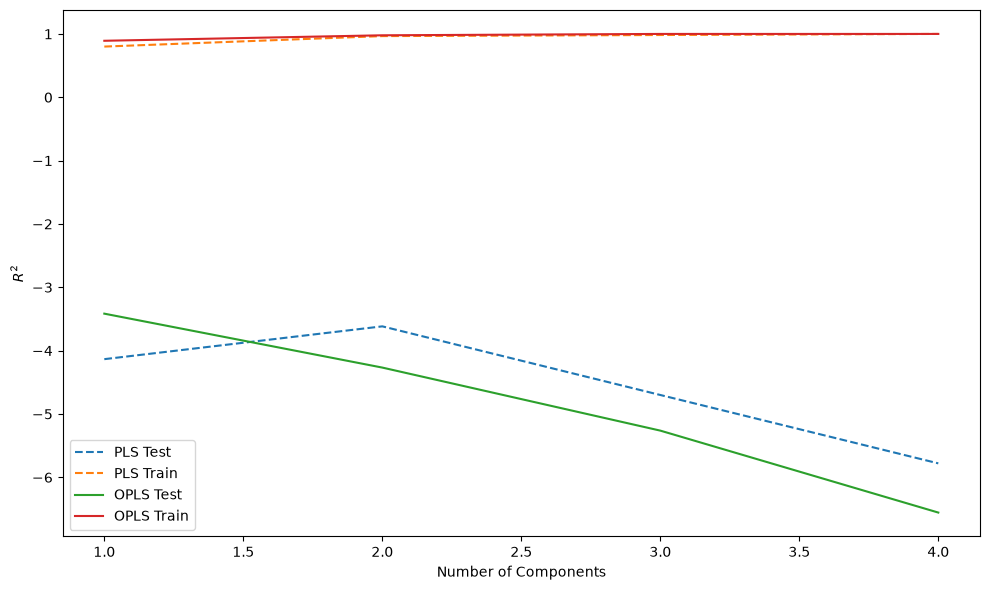

In [37]:
scores = shap_functions.optimize_n_components(X_scaled, Y, maxcomp=4)

In [38]:
print(scores)

(2, 1, 4, 4)


In [39]:
pls = shap_functions.pls_model(X_scaled, Y, 2)

In [40]:
shap_values_pls = shap_functions.compute_shap_values(pls, X_scaled)

In [41]:
opls = shap_functions.opls_model(X_scaled, Y, 2)

In [ ]:
opls_shap = shap_functions.compute_opls_shap_values(opls, X_scaled)

ExactExplainer explainer: 12it [00:16,  1.47s/it]                        
